# Mode masking in the $(k_\perp, k_\parallel)$ plane

Build a mask interactively — wedge cut, rectangular limits, carved-out regions —
and see the spherical power spectrum update, for **one or both** variants.

Nothing re-runs the pipeline: everything downstream of the mask ($X$, `sigma`, the
binning, $\Delta^2(k)$) is recomputed from the stored `pk` and `dpkn`.

**Masks are per grid.** The variants have different $N_E$ (668 with SCF, 760
without), so their $k_\parallel$ axes differ and a mask array built for one cannot
be applied to the other. Share the *specification*, build the array per run —
`msk.for_run` does that.

In [1]:
BASE = '/scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_HF_RA39p7/ps_run_RA_39p7DEG'

# one or both; order sets the legend order
VARIANTS = ['without_SCF', 'with_SCF']

# SCF smoothing scale of these runs; the products do not record it, and the
# k_para floor scales as 1/(r' * SM).
SM_MHZ = 2.0

import numpy as np
import matplotlib.pyplot as plt

from myutils.config import load
import myutils.plots as mp
import myutils.masking as msk
import myutils.reference as rf

%matplotlib inline
mp.style()

runs, cfgs = {}, {}
for v in VARIANTS:
    cfgs[v] = load(f'{BASE}/{v}/config.{v}.yaml')
    runs[v] = mp.load_run(cfgs[v].paths.output_dir)

NBIN = int(cfgs[VARIANTS[0]].power_spectrum.NBin)

for v, d in runs.items():
    print(f'{v:<14s} NE={int(d["NE"]):<4d} fac={float(d["fac"]):.3f}  '
          f'k_para {d["kpara"].min():.4f}-{d["kpara"].max():.4f}  '
          f'({d["kpara"].size} values)')

Imported myutils
         Of 20 annular bins: 1 fall entirely beyond it and will be empty, 1 straddle it and will be under-filled.
         nside_auto is off, so nside stays 512. To keep every bin either raise nside to >= 546, or lower binning.binUmax to <= 244.
         Of 20 annular bins: 1 fall entirely beyond it and will be empty, 1 straddle it and will be under-filled.
         nside_auto is off, so nside stays 512. To keep every bin either raise nside to >= 546, or lower binning.binUmax to <= 244.
without_SCF    NE=760  fac=3.078  k_para 0.0000-5.0484  (760 values)
with_SCF       NE=668  fac=3.078  k_para 0.0000-5.0484  (668 values)


## 1 · The mask specification

**Set `MODE` in the next cell.** That is the one knob; everything else follows.

| `MODE` | wedge | k limits | streak windows |
|---|---|---|---|
| `'wedge_only'` | always | — | — |
| `'paper'` | always | ✓ TTGE III | ✓ |
| `'paper_box'` | always | ✓ TTGE III | — |
| `'custom'` | always | ✓ **yours** | your choice |

### Where do I put my own $k_\perp$ / $k_\parallel$ ranges?

Set `MODE = 'custom'` and edit `KPERP_MIN/MAX` and `KPARA_MIN/MAX` in **section 3**
of the next cell. `None` on any of them means unbounded on that side. Those four
numbers are ignored in the other modes — the presets carry their own.

### What if I want the wedge and nothing else?

`MODE = 'wedge_only'`.

### The wedge is always on

There is no switch. A spherical average that includes the wedge measures
foregrounds, not the 21-cm signal. Only `WEDGE_BUFFER` is tunable — extra
$k_\parallel$ above the horizon line $[k_\parallel]_H = \mathrm{fac}\cdot k_\perp$,
worth using because the wedge edge is soft.

### What `paper` is

The published mode selection of **TTGE III** (Sarkar et al. 2026,
[arXiv:2604.24144](https://arxiv.org/abs/2604.24144), in `Documentation/`):

- $k_\perp \le 0.045\ \mathrm{Mpc}^{-1}$ — beyond that the wedge boundary rises above the SCF smoothing scale, so filtering alone cannot clean the long baselines
- $k_\parallel \ge 0.135\ \mathrm{Mpc}^{-1}$ — below this SCF itself removes power. **Tied to the 2 MHz smoothing scale**, which is what this pipeline uses
- $k_\parallel \le 1.399\ \mathrm{Mpc}^{-1}$ — above that the estimate is noise-dominated
- inside that box, per-$k_\perp$ windows mask the contaminated streaks (their Figure 5)

The cell prints what is actually in effect, with the numbers filled in, so you never
have to guess what a preset resolved to.

In [2]:
# ══════════════════════════════════════════════════════════════════════
#  1 · Pick a mode
# ══════════════════════════════════════════════════════════════════════
MODE = 'paper'      # 'wedge_only' | 'paper' | 'paper_box' | 'custom'
#
#   wedge_only  nothing but the wedge — the widest selection there is
#   paper       TTGE III: k limits + streak windows
#   paper_box   TTGE III k limits, no streak windows
#   custom      your own numbers, from section 3 below

# ══════════════════════════════════════════════════════════════════════
#  2 · The wedge — applied in EVERY mode above. Only the buffer is yours.
# ══════════════════════════════════════════════════════════════════════
WEDGE_BUFFER = 0.0          # Mpc^-1 above the horizon line fac*k_perp

# ══════════════════════════════════════════════════════════════════════
#  3 · Your own k ranges — used ONLY when MODE = 'custom'
# ══════════════════════════════════════════════════════════════════════
KPERP_MIN, KPERP_MAX = 0.007, 0.045     # None = unbounded
KPARA_MIN, KPARA_MAX = 0.135, 1.399     # None = unbounded
USE_TABULATED        = False            # per-k_perp streak windows too?

# extra regions to carve out on top of all of the above:
#   (kperp_lo, kperp_hi, kpara_lo, kpara_hi), None = open edge
BOXES = []

# ── assemble ──────────────────────────────────────────────────────────
if MODE == 'custom':
    SPEC = dict(
        wedge_buffer      = WEDGE_BUFFER,
        use_limits        = True,
        kperp_min = KPERP_MIN, kperp_max = KPERP_MAX,
        kpara_min = KPARA_MIN, kpara_max = KPARA_MAX,
        use_tabulated     = USE_TABULATED,
        kpara_ranges      = msk.PAPER['kpara_ranges'],
        kpara_start_index = msk.PAPER['kpara_start_index'],
    )
else:
    SPEC = dict(preset=MODE, wedge_buffer=WEDGE_BUFFER)


# The paper's limits are absolute k values calibrated at 154.2 MHz; masking
# rescales them to whatever band a run came from. Resolve against a real run so
# what is printed is what gets applied, not the published numbers.
GEOM = msk.geom_of(runs[VARIANTS[0]], SM_mhz=SM_MHZ)


def show(spec, geom=GEOM):
    """What is actually in effect, with the numbers filled in."""
    r = msk.resolve_spec(spec, geom)
    lim_keys = ('kperp_min', 'kperp_max', 'kpara_min', 'kpara_max')
    on = r.get('use_limits', any(r.get(k) is not None for k in lim_keys))
    f = lambda v: 'none' if v is None else f'{v:g}'
    print(f'MODE = {MODE!r}')
    if geom:
        print(f"  band            nu_c = {geom['nuc_mhz']:.4f} MHz   "
              f"r' = {geom['rprime']:.4f}   SM = {geom['SM_mhz']:g} MHz")
    print(f"  wedge           ALWAYS   buffer = {r.get('wedge_buffer') or 0.0:g}")
    print(f"  k limits        {'ON     ' if on else 'off    '}  "
          f"k_perp {f(r.get('kperp_min'))} .. {f(r.get('kperp_max'))}   "
          f"k_para {f(r.get('kpara_min'))} .. {f(r.get('kpara_max'))}")
    print(f"  streak windows  {'ON' if r.get('use_tabulated') else 'off'}")
    print(f"  extra boxes     {len(BOXES)}")

show(SPEC)
print()

masks = {}
for v, d in runs.items():
    m, parts = msk.for_run(d, SPEC, BOXES)
    masks[v] = m
    print(f'=== {v} ===')
    print(msk.describe(parts, d['kper'], d['kpara'], m))
    if 'boxes_removed' in parts:
        print(f"  removed by {len(BOXES)} box(es)   {parts['boxes_removed']:,}")
    print()

Imported psfuncs,   Import Time : 29/07/26 | 08:51:45 PM
MODE = 'paper'
  band            nu_c = 182.4150 MHz   r' = 15.5573   SM = 2 MHz
  wedge           ALWAYS   buffer = 0
  k limits        ON       k_perp 0.00871463 .. 0.0560226   k_para 0.146941 .. 1.52275
  streak windows  ON
  extra boxes     0

=== without_SCF ===
  modes available              15,200
  outside the wedge [always]   14,304
  inside k limits              1,236
  in tabulated windows         561
  selected (all combined)      561 (3.7%)
  k_perp spanned               0.0097 - 0.0556 Mpc^-1
  k_para spanned               0.1530 - 1.5099 Mpc^-1

=== with_SCF ===
  modes available              13,360
  outside the wedge [always]   12,570
  inside k limits              1,092
  in tabulated windows         488
  selected (all combined)      488 (3.7%)
  k_perp spanned               0.0097 - 0.0556 Mpc^-1
  k_para spanned               0.1514 - 1.5062 Mpc^-1



## 2 · See what survives

The cylindrical PS with the excluded region greyed out and the wedge drawn. Check
this before trusting a mask — a stray box is obvious here and invisible in numbers.

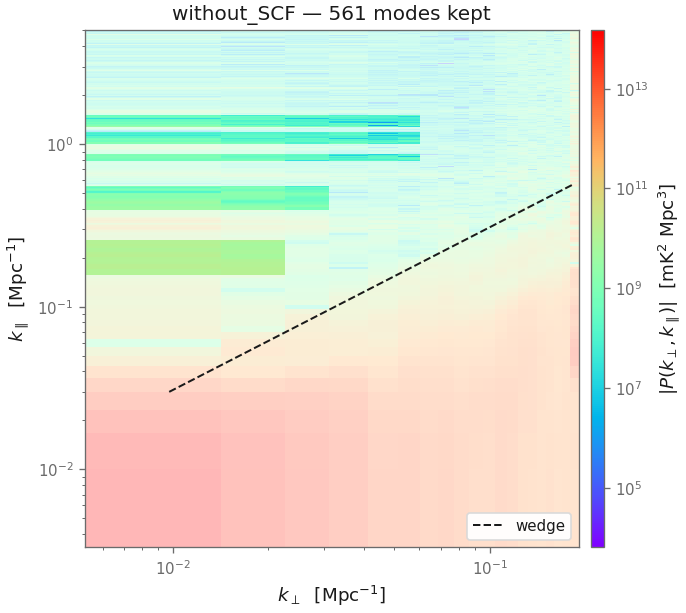

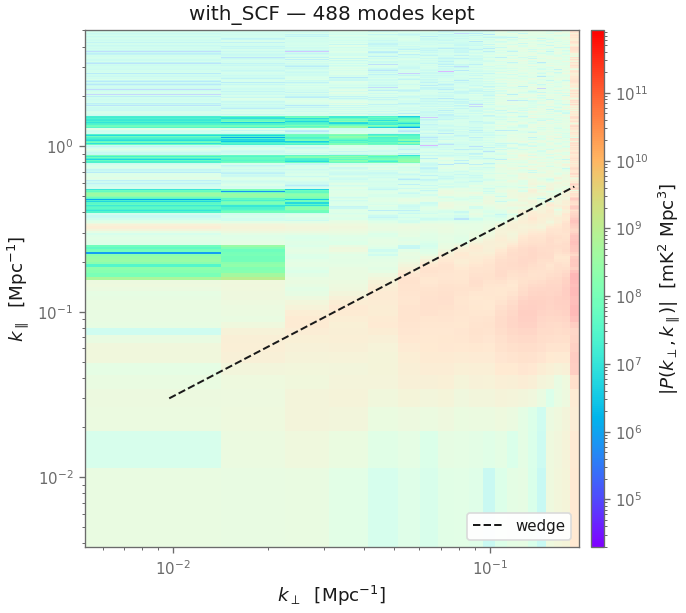

In [3]:
for v in VARIANTS:
    fig = mp.mask_overlay(runs[v], masks[v],
                          title=f'{v} — {int(masks[v].sum()):,} modes kept')
    display(fig); plt.close(fig)

## 3 · The power spectrum under this mask

`sigma` should sit near 1. A mask that pulls it far away is admitting modes the
noise model does not describe.

In [4]:
results = {}
for v in VARIANTS:
    r = msk.recompute(runs[v], masks[v], nbin=NBIN)
    results[v] = r
    print(f'{v:<14s} modes {r["nmodes"]:>7,}   sigma {r["sigma"]:>8.3f}   '
          f'mu {r["mu"]:>7.3f}   bins {len(r["kk"])}')

Bin count   : [ 24   6  51  18 180 282]

without_SCF    modes     561   sigma   11.757   mu   0.530   bins 6
Bin count   : [ 20   6  45  15 158 244]

with_SCF       modes     488   sigma    0.587   mu   0.083   bins 6


In [5]:
for v in VARIANTS:
    r = results[v]
    print(f'=== {v}   (sigma = {r["sigma"]:.3f}) ===')
    print(f"{'k [1/Mpc]':>11}  {'Delta^2':>13}  {'2 sigma':>13}  {'SNR':>8}  {'upper limit':>13}")
    for i in range(len(r['kk'])):
        print(f"{r['kk'][i]:11.4f}  {r['dk2'][i]:13.3e}  {r['dpk2'][i]:13.3e}"
              f"  {r['snr'][i]:8.3f}  {r['ul'][i]:13.3e}")
    print()

=== without_SCF   (sigma = 11.757) ===
  k [1/Mpc]        Delta^2        2 sigma       SNR    upper limit
     0.1937      8.052e+05      3.856e+05     4.177      1.191e+06
     0.2391      1.782e+06      1.285e+06     2.773      3.067e+06
     0.4512     -2.179e+06      3.948e+06    -1.104      3.948e+06
     0.5227      7.255e+05      9.294e+06     0.156      1.002e+07
     0.9454      3.147e+06      2.276e+07     0.277      2.590e+07
     1.3372      1.699e+07      5.303e+07     0.641      7.002e+07

=== with_SCF   (sigma = 0.587) ===
  k [1/Mpc]        Delta^2        2 sigma       SNR    upper limit
     0.1775      9.234e+04      1.444e+04    12.792      1.068e+05
     0.2353      6.141e+04      5.832e+04     2.106      1.197e+05
     0.4449      2.417e+05      1.825e+05     2.649      4.242e+05
     0.5213      7.550e+05      4.356e+05     3.466      1.191e+06
     0.9457     -4.748e+05      1.263e+06    -0.752      1.263e+06
     1.3372      9.663e+05      2.852e+06     0.678   

In [6]:
# Published limits to draw alongside. Names from myutils.reference.DATASETS;
# [] for none. ttge3_alpha11 is the like-for-like case — a single pointing centre.
REFERENCE = ['ttge3_alpha11', 'ttge3_case_i']

print(rf.describe('ttge3_alpha11'), '\n')
print(rf.describe('ttge3_case_i'))

TTGE III, best single PC ($\alpha=11^\circ$)
  Sarkar et al. 2026 (arXiv:2604.24144), Table 1   (z = 8.2)
    k [1/Mpc]    Delta^2_UL [mK^2]  quoted
       0.1610            2.997e+04  (173.13)^2
       0.2120            1.201e+05  (346.62)^2
       0.3710            1.336e+06  (1156.05)^2
       0.4430            7.528e+05  (867.62)^2
       0.7410            7.642e+06  (2764.43)^2
       0.9590            7.061e+06  (2657.21)^2
       1.2710            8.720e+06  (2952.88)^2 

TTGE III, Case I (23 PCs combined)
  Sarkar et al. 2026 (arXiv:2604.24144), Table 2   (z = 8.2)
    k [1/Mpc]    Delta^2_UL [mK^2]  quoted
       0.1560            9.736e+03  (98.67)^2
       0.2040            2.209e+04  (148.63)^2
       0.4060            5.573e+05  (746.52)^2
       0.4820            8.905e+05  (943.66)^2
       0.7280            2.804e+06  (1674.52)^2
       0.8170            1.713e+06  (1308.67)^2
       1.0480            6.508e+06  (2551.15)^2
       1.2940            1.433e+07  (3785.13)^

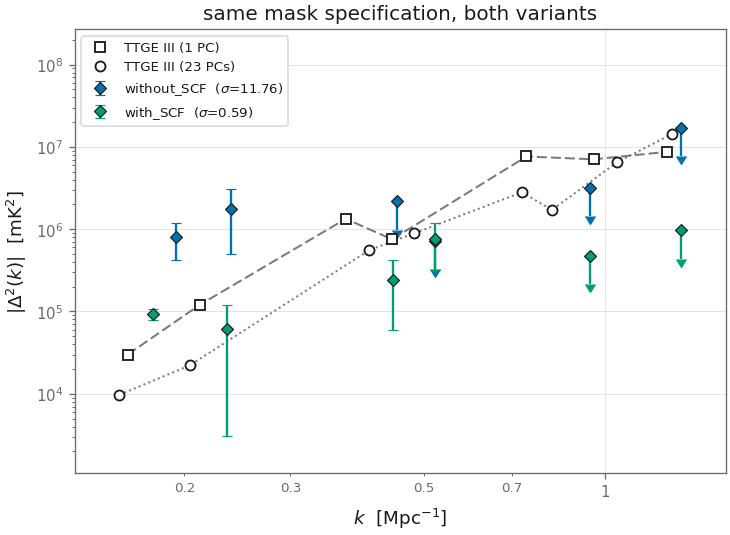

In [7]:
def overlay(res, title, reference=REFERENCE):
    fig, ax = plt.subplots(figsize=(7, 4.8))
    for (name, r), colour in zip(res.items(), mp.PALETTE):
        mag = np.abs(r['dk2'])
        at_zero = r['dpk2'] >= mag
        lower = np.where(at_zero, mag * (1 - 1 / mp.ARROW_DROP), r['dpk2'])
        ax.errorbar(r['kk'], mag, yerr=np.vstack([lower, r['dpk2']]),
                    fmt='D', ms=5, color=colour, mec='#1a1a1a', mew=0.7,
                    elinewidth=1.4, capsize=3, uplims=at_zero,
                    label=f"{name}  ($\\sigma$={r['sigma']:.2f})")

    # neutral ink, distinct marker and dash: a published limit must not be mistaken
    # for one of our runs, and adding one must never recolour a run
    refs = mp.draw_reference(ax, reference)
    span = [r['kk'] for r in res.values()] + \
           [np.array([p['k'] for p in ds['points']]) for ds in refs]

    ax.set_yscale('log')
    mp._log_k_axis(ax, np.concatenate(span))
    ax.set_xlabel(r'$k$  [Mpc$^{-1}$]')
    ax.set_ylabel(r'$|\Delta^2(k)|$  [mK$^2$]')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=8)
    ax.margins(x=0.08, y=0.12)
    mp._legend_headroom(ax)
    # close before returning, like mp._finish: under %matplotlib inline an open
    # figure is auto-displayed at cell end and the returned one renders again,
    # giving two identical plots. A closed figure still renders and still saves.
    plt.close(fig)
    return fig

overlay(results, 'same mask specification, both variants')

## 4 · How much does the mask choice matter?

Sweep the wedge buffer. If an upper limit moves a lot, it is driven by a few modes
near the wedge rather than the bulk of the data.

Bin count   : [ 20   6  45  15 158 244]

buffer 0.0   modes     488  sigma   0.587  first bin   9.234e+04  SNR   12.79
Bin count   : [ 20   6  45  15 158 244]

buffer 0.05  modes     488  sigma   0.587  first bin   9.234e+04  SNR   12.79
Bin count   : [ 19   6  45  15 158 244]

buffer 0.1   modes     487  sigma   0.381  first bin   5.336e+04  SNR    9.15
Bin count   : [  2  24  36  65 151 186]

buffer 0.2   modes     464  sigma   0.288  first bin   9.627e+03  SNR    0.35


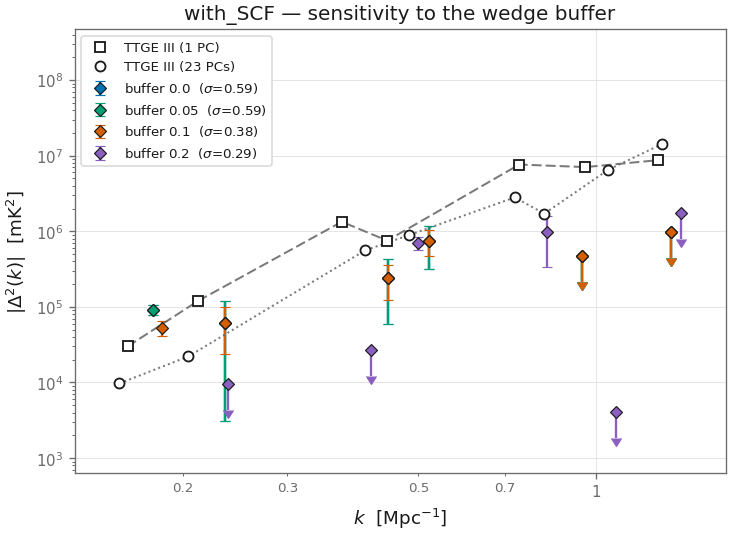

In [8]:
V = VARIANTS[-1]
d = runs[V]

sweep = {}
for buf in (0.0, 0.05, 0.1, 0.2):
    m, _ = msk.for_run(d, dict(SPEC, wedge_buffer=buf), BOXES)
    r = msk.recompute(d, m, nbin=NBIN)
    sweep[f'buffer {buf}'] = r
    print(f'buffer {buf:<5} modes {r["nmodes"]:>7,}  sigma {r["sigma"]:>7.3f}  '
          f'first bin {r["dk2"][0]:>11.3e}  SNR {r["snr"][0]:>7.2f}')

overlay(sweep, f'{V} — sensitivity to the wedge buffer')

## 5 · Keep a mask you like

**Save the arrays** — stage 5 loads `flag_mask.npy` when it exists, so this pins
the exact mask per variant, exclusion boxes included.

In [9]:
for v in VARIANTS:
    path = cfgs[v].power_spectrum.flag_mask
    print(f'{v:<14s} -> {path}')
    # np.save(path, masks[v].astype(int))

without_SCF    -> /scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_HF_RA39p7/ps_run_RA_39p7DEG/without_SCF/flag_mask.npy
with_SCF       -> /scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_HF_RA39p7/ps_run_RA_39p7DEG/with_SCF/flag_mask.npy


**Or describe it in each variant config** — reproducible and self-documenting.
Delete `flag_mask.npy` first; stage 5 prefers the file.

```yaml
power_spectrum:
  mask:
    preset: paper          # TTGE III, arXiv:2604.24144
    wedge_buffer: null     # null = keep what the preset says
```

`preset` plus overrides covers the wedge, the rectangular limits and the streak
windows. Exclusion boxes are notebook-only — save the array if you need them.

Stage 5 prints the resolved preset, so the log records what was applied rather
than what was typed.